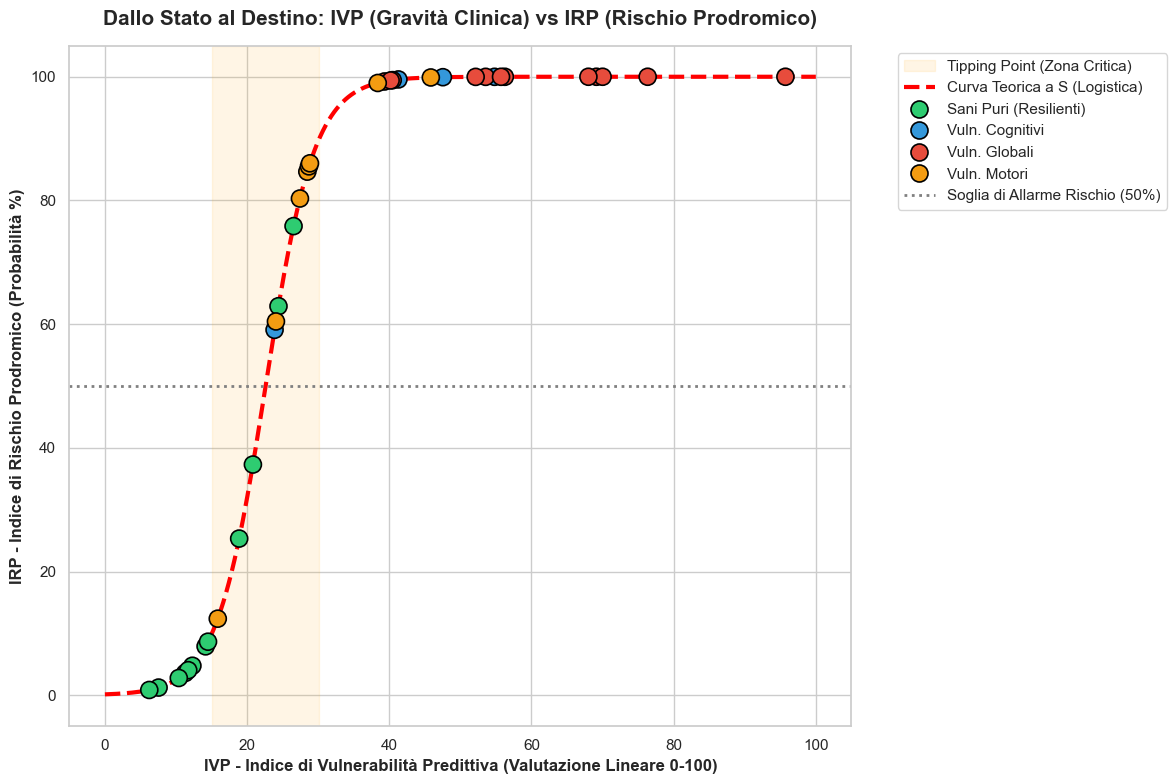


=== VALORI ESATTI DELLE SOGLIE PER LA TESI ===
Inizio Tipping Point (Rischio IRP al 10%): IVP = 15.0
Soglia di Allarme (Rischio IRP al 50%): IVP = 22.6
Fine Tipping Point (Rischio IRP al 90%): IVP = 30.1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

df_clean = pd.read_excel('tabella_36soggetti_fenotipi.xlsx')
df_clean = df_clean.dropna(subset=['Velocità_Hurried_cm/s']).copy()

# Normalizzazione (0-1)
min_eta, max_eta = 66, 91
min_moca, max_moca = 18, 30
min_updrs, max_updrs = 0, 43
min_vel, max_vel = 53.1, 173.2

norm_eta = (df_clean['Età'] - min_eta) / (max_eta - min_eta)
norm_updrs = (df_clean['UPDRS_III'] - min_updrs) / (max_updrs - min_updrs)
norm_moca = (max_moca - df_clean['MoCA']) / (max_moca - min_moca)
norm_vel = (max_vel - df_clean['Velocità_Hurried_cm/s']) / (max_vel - min_vel)

# Nuova formula IVP (Pesi della regressione logistica)
df_clean['IVP_Score'] = (norm_moca * 41.4) + (norm_updrs * 31.8) + (norm_vel * 21.6) + (norm_eta * 5.1)

# Target: 0 = Sano Puro, 1 = Vulnerabile
y = np.where(df_clean['Fenotipo'] == 'Sani Puri (Resilienti)', 0, 1)

# La doppia parentesi o il reshape(-1, 1) evitano l'errore 1D/2D
X = df_clean[['IVP_Score']].values.reshape(-1, 1)

modello_logistico = LogisticRegression()
modello_logistico.fit(X, y)

# Salviamo il rischio percentuale calcolato
df_clean['IRP_Rischio_%'] = modello_logistico.predict_proba(X)[:, 1] * 100

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Colori per i fenotipi
colori_dict = {
    'Sani Puri (Resilienti)': '#2ecc71',
    'Vuln. Cognitivi': '#3498db',
    'Vuln. Motori': '#f39c12',
    'Vuln. Globali': '#e74c3c'
}

x_curve = np.linspace(0, 100, 500).reshape(-1, 1)
y_curve = modello_logistico.predict_proba(x_curve)[:, 1] * 100

# Evidenziamo la "Zona Grigia" (Tipping Point) calcolando dove la curva passa dal 10% al 90%
ivp_10 = x_curve[np.abs(y_curve - 10).argmin()][0]
ivp_90 = x_curve[np.abs(y_curve - 90).argmin()][0]
plt.axvspan(ivp_10, ivp_90, color='orange', alpha=0.1, label='Tipping Point (Zona Critica)')

# Disegniamo la curva
plt.plot(x_curve, y_curve, color='red', linestyle='--', lw=3, label='Curva Teorica a S (Logistica)')

# 3B. Disegniamo i Pazienti Reali (Scatterplot)
sns.scatterplot(
    data=df_clean, x='IVP_Score', y='IRP_Rischio_%',
    hue='Fenotipo', palette=colori_dict,
    s=150, edgecolor='black', linewidth=1.2, zorder=5
)

# Linea soglia rischio 50%
plt.axhline(50, color='gray', linestyle=':', lw=2, label='Soglia di Allarme Rischio (50%)')

plt.title('Dallo Stato al Destino: IVP (Gravità Clinica) vs IRP (Rischio Prodromico)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('IVP - Indice di Vulnerabilità Predittiva (Valutazione Lineare 0-100)', fontsize=12, fontweight='bold')
plt.ylabel('IRP - Indice di Rischio Prodromico (Probabilità %)', fontsize=12, fontweight='bold')

plt.xlim([-5, 105])
plt.ylim([-5, 105])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('16_Curva_Sigmoide_Definitiva.png', dpi=300, bbox_inches='tight')
plt.show()
# Calcoliamo anche l'IVP esatto in cui il rischio taglia il 50%
ivp_50 = x_curve[np.abs(y_curve - 50).argmin()][0]

print("\n=== VALORI ESATTI DELLE SOGLIE PER LA TESI ===")
print(f"Inizio Tipping Point (Rischio IRP al 10%): IVP = {ivp_10:.1f}")
print(f"Soglia di Allarme (Rischio IRP al 50%): IVP = {ivp_50:.1f}")
print(f"Fine Tipping Point (Rischio IRP al 90%): IVP = {ivp_90:.1f}")

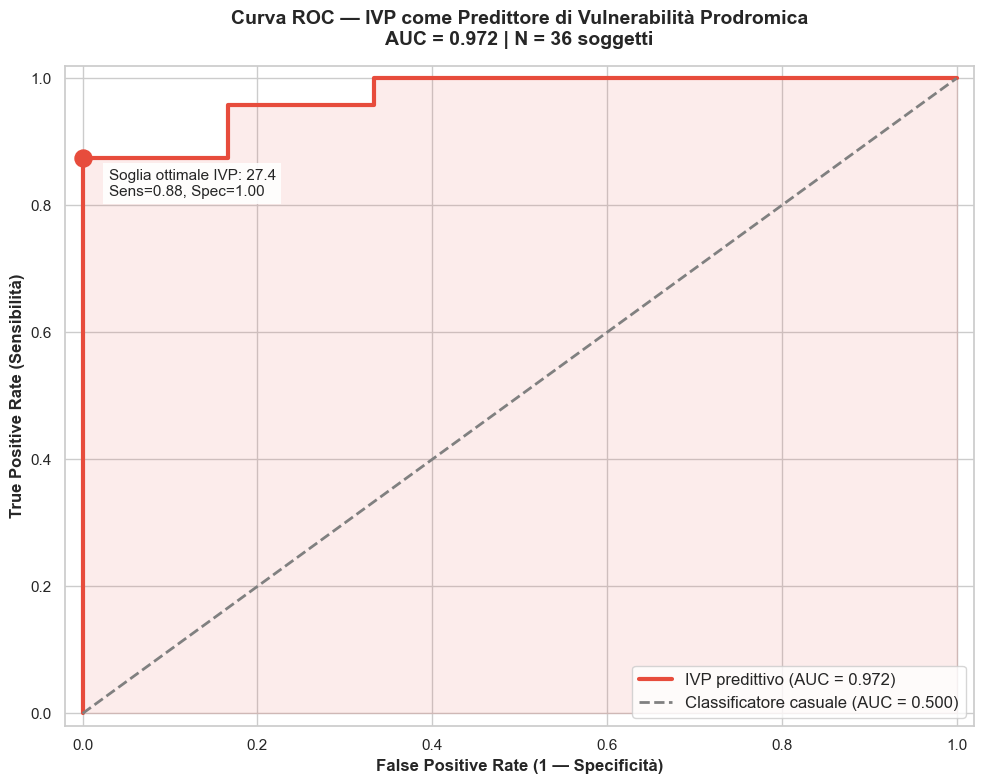

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np

y_true = np.where(df_clean['Fenotipo'] == 'Sani Puri (Resilienti)', 0, 1)

# Calcolo della curva ROC e dell'AUC usando il nuovo IVP_Score
fpr, tpr, thresholds = roc_curve(y_true, df_clean['IVP_Score'])
roc_auc = auc(fpr, tpr)

# Troviamo il punto ottimale (Indice di Youden: massima Sensibilità + Specificità)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_spec = 1 - optimal_fpr

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# Disegniamo la curva ROC (linea rossa spessa)
plt.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'IVP predittivo (AUC = {roc_auc:.3f})')

# Riempiamo l'area sotto la curva per renderla uguale al tuo documento originale
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

# Linea tratteggiata del classificatore casuale (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Classificatore casuale (AUC = 0.500)')

# Aggiungiamo il punto ottimale
plt.scatter(optimal_fpr, optimal_tpr, s=150, color='#e74c3c', zorder=5)
plt.text(optimal_fpr + 0.03, optimal_tpr - 0.06,
         f'Soglia ottimale IVP: {optimal_threshold:.1f}\nSens={optimal_tpr:.2f}, Spec={optimal_spec:.2f}',
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

# Titolo e assi
plt.title(f'Curva ROC — IVP come Predittore di Vulnerabilità Prodromica\nAUC = {roc_auc:.3f} | N = 36 soggetti', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 — Specificità)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensibilità)', fontsize=12, fontweight='bold')

# Limiti del grafico e legenda
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc='lower right', fontsize=12, frameon=True)

plt.tight_layout()
plt.show()